In [1]:
# edge_stgnn_forecast.py
# End-to-end edge-based spatio-temporal GNN for bicycle flow forecasting.
# Requirements: python>=3.9, torch, pandas, numpy, networkx, matplotlib
# pip install torch pandas numpy networkx matplotlib

from __future__ import annotations
from typing import List, Dict, Tuple, Set, Any


import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import os


import matplotlib.pyplot as plt
import networkx as nx
from scripts.preprocessing import Config, NetworkConfig
from scripts import models, preprocessing, features, training, visualisation



e:\Python\Bicycle_Traffic_Flow_GNN\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
'''
to do's:
-fix time offset
-clean up code
-add explinations
-fix time axis for plots
-do gridsearch
-check if sensors are consistent though data
-use ARIMA instead of regression
-add comments and docstrings
'''

"\nto do's:\n-fix time offset\n-clean up code\n-add explinations\n-fix time axis for plots\n-do gridsearch\n-check if sensors are consistent though data\n-use ARIMA instead of regression\n-add comments and docstrings\n"

In [3]:
print("torch", torch.__version__)
print("cuda available?", torch.cuda.is_available())
print("cuda runtime:", torch.version.cuda)
print("device count:", torch.cuda.device_count())

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'  # synchronous CUDA; precise traceback
torch.cuda.empty_cache()

torch 2.8.0+cu128
cuda available? True
cuda runtime: 12.8
device count: 1


In [4]:
# ----------------------------
# 1) Network definition
# ----------------------------

# Nodes
NODES = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P']

# Example coordinates in (x, y). Replace with your true values (meters or canvas units).
POS = {
    'A': (0, 10), 'B': (5, 10),
    'C': (0, 7),  'D': (5, 7),
    'E': (0, 4), 'F': (5, 4), 'G': (9, 4),
    'H': (-3, 1), 'I': (0, 1), 'J': (5, 1), 'K': (9, 1), 'L': (12, 1),
    'M': (0, -2), 'N': (5, -2), 'O': (9, -2),
    'P': (5, -5)
}

# Physical undirected links
PHYSICAL_EDGES = [
    ('A','B'),        # no sensor
    ('A','C'),
    ('C','E'),
    ('B','D'),
    ('D','F'),        # no sensor
    ('C','D'),        # no sensor
    ('D','G'),        # no sensor
    ('G','K'),
    ('K','O'),
    ('H','I'),
    ('I','J'),
    ('J','K'),
    ('K','L'),
    ('E','I'),
    ('F','J'),
    ('J','N'),        # no sensor
    ('N','P'),
    ('I','M'),
    ('M','N'),        # no sensor
    ('N','O')         # no sensor
]

# Edges without sensors (undirected listing). Both directions will be masked.
NO_SENSOR_UNDIR = {('A','B'), ('M','N'), ('N','O'), ('D','G'), ('D','F'), ('J','N'), ('C','D')}

# Map each (sensor_id|element_name) to its BASE direction (u->v).
# count_in goes to (u->v); count_out goes to (v->u).
SENSOR_TO_EDGE: Dict[str, Tuple[str,str]] = {
    "TUD_SBX01|Line 0": ("D", "B"),
    "TUD_SPX18|Line 0": ("A", "C"),
    "TUD_SBX22|Line 0": ("E", "C"),
    "TUD_SBXN6A|Line 2": ("F", "J"),
    "TUD_SBXN6A|Line 0": ("J", "K"),
    "TUD_SPX23|Line 0": ("I", "E"),
    "TUD_SBX25|Line 2": ("I", "H"),
    "TUD_SBX26|Line 0": ("I", "M"),
    "TUD_SPX24|Line 0": ("J", "I"),
    "TUD_SBX07-MULTI|Line 1": ("G", "K"),
    "TUD_SBX07-MULTI|Line 2": ("K", "L"),
    "TUD_SBX07-MULTI|Line 3": ("O", "K"),
    "TUD_SBXN13|Line 0": ("P", "N"),
}

DIRECTED_EDGES = preprocessing.undir_to_dir(PHYSICAL_EDGES)

EDGE_INDEX = {e:i for i,e in enumerate(DIRECTED_EDGES)}
INDEX_EDGE = {i:e for e,i in EDGE_INDEX.items()}

A_line = preprocessing.build_line_graph_adjacency(DIRECTED_EDGES, allow_uturn=False)
A_hat = preprocessing.normalize_adjacency(A_line)

network_cfg = NetworkConfig(
    nodes=NODES,
    pos=POS,
    physical_edges=PHYSICAL_EDGES,
    no_sensor_undir=NO_SENSOR_UNDIR,
    sensor_to_edge=SENSOR_TO_EDGE,
    directed_edges=DIRECTED_EDGES,
    edge_index=EDGE_INDEX,
    index_edge=INDEX_EDGE,
    a_line=A_line,
    a_hat=A_hat
)

In [5]:
# ----------------------------
# 8) Main: wiring everything
# ----------------------------

def run_experiment_in_notebook(
    csv_paths,
    weather_csv=None,
    cfg=None,
    partial_policy="dedupe",   # "dedupe" (keep last per bucket) or "sum" (sum partials)
    print_every=True
):
    """
    csv_paths: list of CSV file paths for your sensors
    weather_csv: optional CSV with weather; must have a 'timestamp' column
    cfg: Config() object; if None, uses defaults from the script
    partial_policy: "dedupe" to drop repeated lines per bucket, or "sum" to sum partial reads
    returns: dict with model, loaders, metrics, times, predictions, etc.
    """
    # 0) config & seed
    if cfg is None:
        cfg = Config()
    features.set_seed(cfg.seed)

    # 1) load raw sensor data (count_in / count_out preserved)
    raw = preprocessing.parse_smartcamera_csv(csv_paths)

    # 2) handle repeated reports in a bin
    if partial_policy == "dedupe":
        raw = preprocessing.dedupe_within_bucket(raw, cfg.time_granularity)
    elif partial_policy == "sum":
        raw = preprocessing.sum_within_bucket(raw, cfg.time_granularity)
    else:
        raise ValueError("partial_policy must be 'dedupe' or 'sum'.")

    # 3) edge-time matrix (routes count_in to (u->v) and count_out to (v->u))
    #    NOTE: build_edge_time_matrix must NOT rely on globals; it should use network_cfg internally or be passed whatever it needs.
    times, X, M = preprocessing.build_edge_time_matrix(raw, cfg, network_cfg)  # X:[T,E], M:[T,E]
    T, E = X.shape

    # Freeze the canonical truth (never overwritten)
    artifacts = {"X_true": X.copy(), "M_obs": M.copy(), "times": times}

    # 3b) graph adjacency for GNN + for neighbor features
    #     A: binary adjacency (float32); A_hat: row-normalized with self-loops for the GNN; A_bin: binary for neighbor-lags.
    A = preprocessing.build_line_graph_adjacency(network_cfg.directed_edges).astype(np.float32)  # [E,E]
    A_hat = features.sanitize_and_row_normalize_A(A)                               # [E,E], float32
    A_bin = (A > 0).astype(np.float32)                                             # [E,E], {0,1}

    # 4) exogenous features (time/day [+weather] + self-lags + neighbor-lags from causal-filled series)
    weather_df = None
    if cfg.use_exog and weather_csv:
        w = pd.read_csv(weather_csv, parse_dates=['timestamp'])
        w = (w.set_index('timestamp')
               .sort_index()
               .resample(cfg.time_granularity)
               .mean())
        weather_df = w.select_dtypes(include=[np.number])

    if cfg.use_exog:
        exog = features.add_exogenous(
            times=times,
            E=E,
            config=cfg,
            weather_df=weather_df,
            X=X, M=M, A_bin=A_bin,          # <-- enables causal fill + self/neighbor lags
            use_graph_fill=True,
            lags_self=(1,2,3,6,12),
            lags_neigh=(1,2,3),
            ema_alpha=0.7,
            fill_weights=(0.7, 0.3, 0.0),   # (EMA, neighbor, pred) — start without preds
            Xhat_prev=None
        )
    else:
        exog = None

    if print_every:
        print("exog shape:", None if exog is None else exog.shape)  # expect [T, E, F]

    # 5) chronological split
    n = len(times)
    n_train = int(0.7 * n)
    n_val   = int(0.15 * n)
    slices = {
        "train": slice(0, n_train),
        "val":   slice(n_train, n_train + n_val),
        "test":  slice(n_train + n_val, n)
    }

    loaders = {}
    for split, s in slices.items():
        ds = preprocessing.WindowedEdgeDataset(
            X[s], M[s],
            exog[s] if exog is not None else None,
            cfg.H_in, cfg.H_out
        )
        loaders[split] = DataLoader(
            ds,
            batch_size=cfg.batch_size,
            shuffle=(split == "train"),
            drop_last=True,
            pin_memory=cfg.device.startswith("cuda")
        )
    
    # Make and attach the hook (prediction-driven neighbor lags)
    epoch_hook = training.make_prediction_driven_hook(
        X, M, times, E, cfg, weather_df, A_bin, slices, loaders,
        lags_self=(1,2,3,6,12), lags_neigh=(1,2,3),
        ema_alpha=0.7, fill_weights=(0.5,0.3,0.2),
        current_exog_container={"arr": exog}   # start from current exog
    )

    # 6) model
    F_in = 1 + (exog.shape[-1] if exog is not None else 0)
    model = models.EdgeSTGNN(
        E=E, F_in=F_in, H_out=cfg.H_out,
        A_hat=A_hat, nblocks=cfg.nblocks, hidden=cfg.hidden, dropout=cfg.dropout
        # A_hat=A_hat, nblocks=
    )

    # 7) train
    if print_every:
        print(f"Device: {cfg.device} | Samples: {n} | Edges (directed): {E}")
    model = training.train_model(model, loaders, cfg, epoch_hook=epoch_hook, A_bin=A_bin)

    # 8) evaluate
    metrics = training.evaluate(model, loaders["test"], cfg.device)
    if print_every:
        print("Test metrics:", metrics)

    # 9) example prediction (first batch, first horizon)
    batch = next(iter(loaders["test"]))
    with torch.no_grad():
        yhat = model(batch["x"].to(cfg.device)).cpu().numpy()  # [B,H_out,E]

    # map back to edges in the same order used by the model (network_cfg.directed_edges)
    pred_edge_step0 = {
        network_cfg.directed_edges[i]: float(yhat[0, 0, i])
        for i in range(yhat.shape[-1])
    }

    # Optional: draw
    visualisation.draw_network_flows(
        pred_edge_step0,
        title="Predicted flows (first forecast step)",
        network_cfg=network_cfg
    )

    return {
        "model": model,
        "cfg": cfg,
        "loaders": loaders,
        "times": times,
        "X": X,
        "M": M,
        "A": A,
        "A_hat": A_hat,
        "A_bin": A_bin,
        "exog": exog,
        "metrics_test": metrics,
        "yhat_example": yhat,
        "pred_edge_step0": pred_edge_step0,
        # canonical truth (use these in plots/metrics)
        "X_true": artifacts["X_true"],
        "M_obs": artifacts["M_obs"],
    }


exog shape: (11521, 40, 12)
Device: cuda | Samples: 11521 | Edges (directed): 40


Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

epoch 001  train_mae=1.1290  val_mae=1.1814


Epochs:   5%|▌         | 1/20 [00:05<01:40,  5.27s/it]

[hook] Rebuilt exog with preds at epoch 1 (weights=(0.5, 0.3, 0.2)); loaders updated.
epoch 002  train_mae=0.9348  val_mae=0.8711


...

Epochs:  95%|█████████▌| 19/20 [01:31<00:04,  4.73s/it]

[hook] Rebuilt exog with preds at epoch 19 (weights=(0.5, 0.3, 0.2)); loaders updated.
epoch 020  train_mae=0.5903  val_mae=0.7228


Epochs: 100%|██████████| 20/20 [01:35<00:00,  4.79s/it]

[hook] Rebuilt exog with preds at epoch 20 (weights=(0.5, 0.3, 0.2)); loaders updated.


Test metrics: {'MAE': 0.6930923831063011, 'RMSE': 2.1983619487857835}


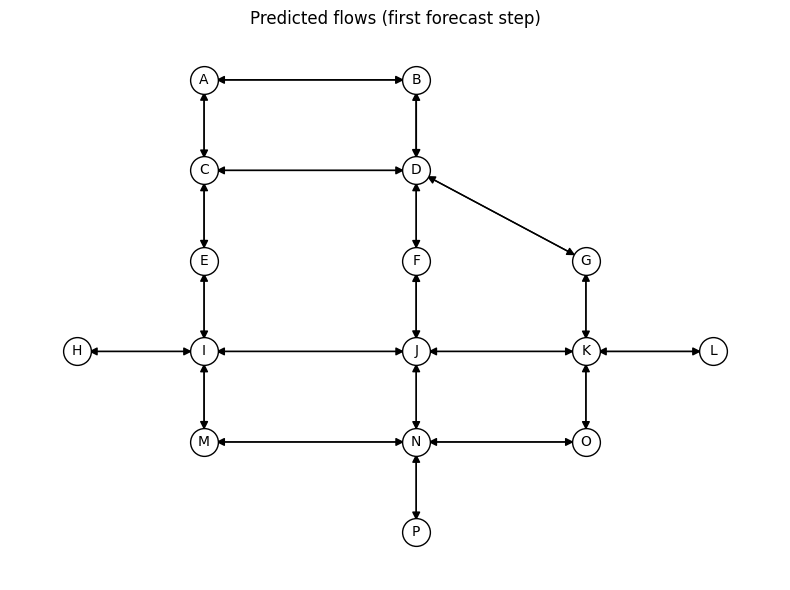

Test: {'MAE': 0.6930923831063011, 'RMSE': 2.1983619487857835}
('A', 'B') 1.789420247077942
('B', 'A') 0.017268741503357887
('A', 'C') 0.40409570932388306
('C', 'A') 0.022998442873358727
('C', 'E') 1.4267767667770386
('E', 'C') 0.0012851384235545993
('B', 'D') 4.049498558044434
('D', 'B') 1.14849054813385
('D', 'F') 0.8271298408508301
('F', 'D') 0.07673974335193634


In [6]:
# Ensure inline plotting in notebooks
%matplotlib inline

# 1) Fill in your mapping and coordinates BEFORE running this cell:
#    - SENSOR_TO_EDGE  (base directions)
#    - POS             (exact coordinates)

csv_paths = [
    "data/smartcameras_line--2025-01-01T03-01-00--2025-02-01T03-01-00--tud_project--y16mv1.csv",
    "data/smartcameras_line--2025-02-01T03-01-00--2025-03-01T03-01-00--tud_project--bvtmix.csv",
    "data/smartcameras_line--2025-03-01T03-01-00--2025-04-01T03-01-00--tud_project--a93fyx.csv",
    "data/smartcameras_line--2025-04-01T03-01-00--2025-05-01T03-01-00--tud_project--henvbs.csv"
]
weather_csv = None  # or a path like "/content/data/weather_5min_2025.csv"

time_granularity = "15min"
H_in = features.steps_for_hours(time_granularity, 6)          # hours in the past
H_out = features.steps_for_hours(time_granularity, 3)         # hours in the future

cfg = Config(
    time_granularity = time_granularity,
    H_in = H_in,
    H_out = H_out,
    batch_size=64,
    lr=1e-4,
    max_epochs=20,
    patience=8,
    device="cuda" if torch.cuda.is_available() else "cpu",
    seed=42,
    use_exog=True,
    gcn_type="cheb",     # or "gcn"
    cheb_K=3,            # 2–4 is typical
    nblocks=2,           # gives 1–2–4 dilations
    hidden=32,
    dropout=0.12,
    lambda_lap=1e-3 
)

artifacts = run_experiment_in_notebook(
    csv_paths=csv_paths,
    weather_csv=weather_csv,
    cfg=cfg,
    partial_policy="dedupe",   # or "sum" if your device sends partials within a bin
    print_every=True
)

# Access results:
print("Test:", artifacts["metrics_test"])
# Example: inspect one predicted vector for the first sample & first horizon
E = len(DIRECTED_EDGES)
first_pred = artifacts["yhat_example"][0,0,:].reshape(E)
for i, val in enumerate(first_pred[:10]):  # show first 10 edges
    print(INDEX_EDGE[i], float(val))


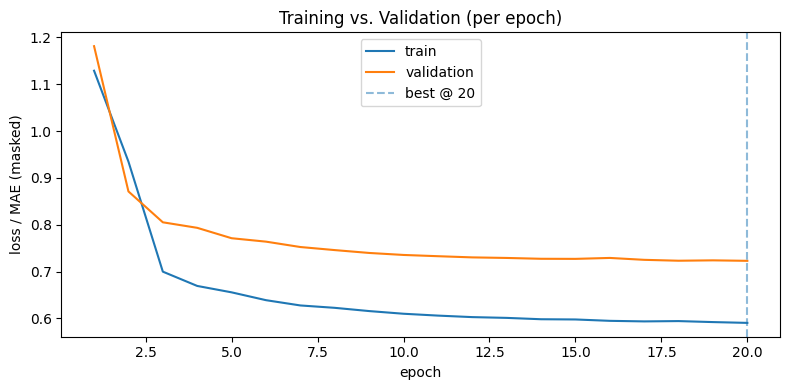

[1.128972692489624, 0.9347851085662842, 0.6997182006835938, 0.6691924457550049, 0.6555103695392609, 0.6387786149978638, 0.627504542350769, 0.6224186232089997, 0.6155008178949356, 0.6097878446578979, 0.6058254039287567, 0.6025944986343383, 0.6009421896934509, 0.59805357670784, 0.5975651483535767, 0.5946368265151978, 0.593436443567276, 0.5940977137088775, 0.5919733848571778, 0.5902578814029693]


In [7]:
import numpy as np
import matplotlib.pyplot as plt

h = getattr(artifacts["model"], "history", None)
if not h:
    raise RuntimeError("No history found. Re-run training after replacing train_model.")

epochs = np.array(h["epoch"])
train  = np.array(h["train"])
val    = np.array(h["val"])
best_ix = int(np.argmin(val))

plt.figure(figsize=(8,4))
plt.plot(epochs, train, label="train")
plt.plot(epochs, val,   label="validation")
plt.axvline(epochs[best_ix], linestyle="--", alpha=0.5, label=f"best @ {epochs[best_ix]}")
plt.title("Training vs. Validation (per epoch)")
plt.xlabel("epoch")
plt.ylabel("loss / MAE (masked)")
plt.legend()
plt.tight_layout()
plt.show()

print(h["train"])

In [8]:
# pull from your earlier 'artifacts' dict
model = artifacts["model"]
cfg = artifacts["cfg"]
times = artifacts["times"]
test_ds = artifacts["loaders"]["test"].dataset

# reconstruct where TEST starts in the global timeline (60/20/20 split)
n = len(times)
n_train = int(0.6 * n)
n_val   = int(0.2 * n)
test_start = n_train + n_val

H_in, H_out = cfg.H_in, cfg.H_out
E = len(DIRECTED_EDGES)

# make an eval loader that does NOT drop the final, partial batch
eval_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    drop_last=False,
    pin_memory=cfg.device.startswith("cuda")
)

preds, trues, masks = [], [], []

model.eval()
with torch.no_grad():
    for batch in eval_loader:
        x = batch["x"].to(cfg.device, non_blocking=True)
        y = batch["y"].to(cfg.device, non_blocking=True)
        m = batch["mask"].to(cfg.device, non_blocking=True)
        yhat = model(x)                              # [B, H_out, E]
        preds.append(yhat.cpu().numpy())
        trues.append(y.cpu().numpy())
        masks.append(m.cpu().numpy())

YH = np.concatenate(preds, axis=0)  # [N_eff, H_out, E]
Y  = np.concatenate(trues, axis=0)  # [N_eff, H_out, E]
M  = np.concatenate(masks, axis=0)  # [N_eff, H_out, E]
N_eff = YH.shape[0]

# build a tidy table with timestamp, horizon, edge (u->v), pred/true/observed
records = []
for i in range(N_eff):
    t_start = test_start + H_in + i             # absolute index where this forecast window starts
    for h in range(H_out):
        t_abs = t_start + h
        ts = times[t_abs]
        for e_idx, (u, v) in enumerate(DIRECTED_EDGES):
            records.append({
                "timestamp": ts,
                "h": h,                         # 0 = first step ahead
                "u": u,
                "v": v,
                "edge": f"{u}->{v}",
                "pred": float(YH[i, h, e_idx]),
                "true": float(Y[i, h, e_idx]),
                "observed": bool(M[i, h, e_idx] > 0.5),
            })

df_pred = (pd.DataFrame.from_records(records)
          .sort_values(["timestamp", "h", "u", "v"])
          .reset_index(drop=True))

# show the full table (can be large)
df_pred


,timestamp,h,u,v,edge,pred,true,observed
0,2025-04-07 09:00:00,0,A,B,A->B,1.789420e+00,0.0,False
1,2025-04-07 09:00:00,0,A,C,A->C,4.040957e-01,1.0,True
2,2025-04-07 09:00:00,0,B,A,B->A,1.726874e-02,0.0,False
3,2025-04-07 09:00:00,0,B,D,B->D,4.049499e+00,3.0,True
4,2025-04-07 09:00:00,0,C,A,C->A,2.299844e-02,0.0,True
...,...,...,...,...,...,...,...,...
813115,2025-04-25 03:00:00,11,N,O,N->O,1.410165e-14,0.0,False
813116,2025-04-25 03:00:00,11,N,P,N->P,1.752740e-15,0.0,True
813117,2025-04-25 03:00:00,11,O,K,O->K,1.205039e-15,0.0,True
813118,2025-04-25 03:00:00,11,O,N,O->N,1.058385e-14,0.0,False


In [9]:
# # === Pre-flight checks (run before the training cell) ===
# from pathlib import Path
# import pandas as pd
# import numpy as np

# # 0) File exists?
# for p in [
#     "data/smartcameras_line--2025-01-01T03-01-00--2025-02-01T03-01-00--tud_project--y16mv1.csv"
# ]:
#     if not Path(p).exists():
#         raise FileNotFoundError(f"CSV not found: {p}")
# print("✓ CSV found")

# # 1) Peek at the CSV schema quickly
# peek = pd.read_csv(
#     "data/smartcameras_line--2025-01-01T03-01-00--2025-02-01T03-01-00--tud_project--y16mv1.csv",
#     nrows=5
# )
# print("Columns:", list(peek.columns))

# required_cols = {"sensor_id","element_name","start_time","count_in","count_out"}
# missing = required_cols - set(peek.columns)
# if missing:
#     raise ValueError(f"CSV missing required columns: {missing}")
# print("✓ Required columns present")

# # 2) Mapping coverage sanity check (quick sample of keys)
# raw_sample = pd.read_csv(
#     "data/smartcameras_line--2025-01-01T03-01-00--2025-02-01T03-01-00--tud_project--y16mv1.csv",
#     usecols=["sensor_id","element_name"], nrows=5000
# )
# raw_sample["sensor_key"] = raw_sample["sensor_id"].astype(str) + "|" + raw_sample["element_name"].astype(str)
# all_keys = set(raw_sample["sensor_key"].unique())
# mapped_keys = set(SENSOR_TO_EDGE.keys())

# unmapped = sorted(all_keys - mapped_keys)
# print(f"Mapped keys in dict: {len(mapped_keys)} | Keys seen in sample: {len(all_keys)}")
# if unmapped:
#     print("⚠ Unmapped sensor keys (first 20):", unmapped[:20])
#     # Not fatal, but you’ll get zeros on those edges; add them to SENSOR_TO_EDGE when possible.
# else:
#     print("✓ All sampled keys are mapped")

# # 3) Coordinates present?
# if not POS:
#     raise ValueError("POS (node coordinates) is empty. Fill POS before training.")
# unknown_nodes = [n for n in NODES if n not in POS]
# if unknown_nodes:
#     raise ValueError(f"Missing coordinates for nodes: {unknown_nodes}")
# print("✓ Coordinates loaded for all nodes")

# # 4) Presence-based mask function in use?
# try:
#     preprocessing.build_edge_time_matrix  # function must exist
#     print("✓ build_edge_time_matrix is defined")
# except NameError:
#     raise RuntimeError("build_edge_time_matrix is not defined in this notebook session.")

# print("Pre-flight checks passed.")


In [10]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # # pick the edge and the calendar day you want to visualise
# # edge_uv = ('B','D')            # <-- change me
# # day_str = '2025-01-30'         # <-- change me (YYYY-MM-DD)

# # edge_str = f"{edge_uv[0]}->{edge_uv[1]}"
# # day = pd.to_datetime(day_str).date()

# # # filter to that edge & day
# # sel = df_pred[(df_pred['edge'] == edge_str) &
# #               (df_pred['timestamp'].dt.date == day)].copy()

# # # keep only bins with ground truth (observed)
# # sel_true = sel[sel['observed']].copy()

# # # sort & drop duplicates (shouldn’t exist, but safe)
# # sel = sel.sort_values(['timestamp','h'])
# # sel_true = sel_true.sort_values(['timestamp','h'])

# # # build time series (one point per timestamp)
# # ts_pred = sel.groupby('timestamp', as_index=True)['pred'].mean()
# # ts_true = sel_true.groupby('timestamp', as_index=True)['true'].mean()

# edge_uv = ('B','D')           # <-- change me
# day_str = '2025-04-24'        # <-- change me (YYYY-MM-DD)

# edge_str = f'{edge_uv[0]}->{edge_uv[1]}'
# sel = df_pred[(df_pred['edge']==edge_str) &
#               (df_pred['timestamp'].dt.date==pd.to_datetime(day_str).date())]

# # keep the *smallest* horizon per timestamp
# sel = (sel.sort_values(['timestamp','h'])
#            .drop_duplicates(['timestamp','edge'], keep='first'))

# ts_pred = sel.set_index('timestamp')['pred']
# ts_true = sel[sel['observed']].set_index('timestamp')['true']


# # compute metrics on common timestamps with truth
# common_idx = ts_true.index.intersection(ts_pred.index)
# mae = float(np.mean(np.abs(ts_pred.reindex(common_idx) - ts_true.reindex(common_idx))))
# rmse = float(np.sqrt(np.mean((ts_pred.reindex(common_idx) - ts_true.reindex(common_idx))**2)))
# print(f"{edge_str} — {day_str}  MAE={mae:.3f}, RMSE={rmse:.3f}  (on observed bins)")

# # plot
# plt.figure(figsize=(10,4))
# plt.plot(ts_pred.index, ts_pred.values, label='prediction')
# plt.plot(ts_true.index, ts_true.values, label='truth (observed)')
# plt.title(f"{edge_str} — {day_str}")
# plt.xlabel("time")
# plt.ylabel("cyclists / 5 min")
# plt.legend()
# plt.tight_layout()
# plt.show()


B->D — 2025-04-24  MAE=1.906, RMSE=5.061  (on observed bins)


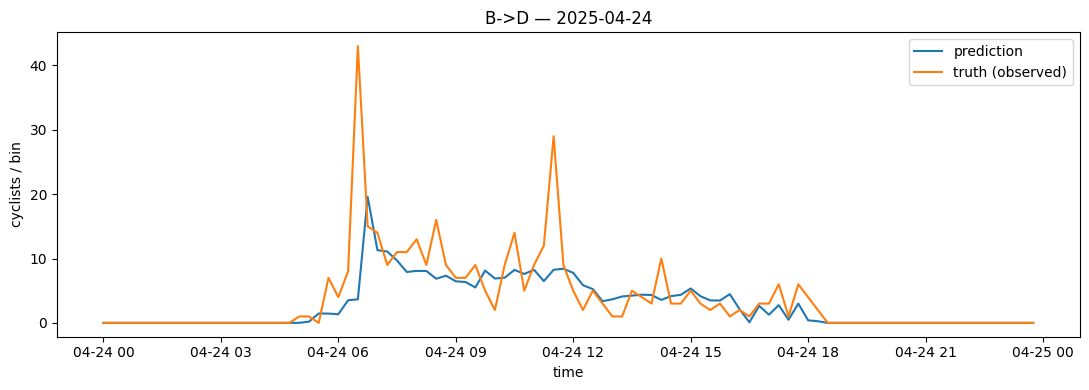

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- inputs you already have ---
# artifacts: dict with "X_true", "M_obs", "times" (frozen at load time)
# network_cfg.directed_edges: list of (u,v) in the exact model order
# df_pred: long dataframe with columns ['timestamp','h','u','v','edge','pred','true','observed']

# pick what to plot
edge_uv = ('B','D')           # <--- change me
day_str = '2025-04-24'        # <--- change me
edge_str = f"{edge_uv[0]}->{edge_uv[1]}"
day = pd.to_datetime(day_str).date()

# ---- 1) Build TRUTH series from the frozen arrays ----
times   = artifacts["times"]
X_true  = artifacts["X_true"]    # [T,E], raw counts (no imputation)
M_obs   = artifacts["M_obs"]     # [T,E], 1 if observed

# find column index for this edge
edge_list = list(network_cfg.directed_edges)
try:
    e_idx = edge_list.index(edge_uv)
except ValueError:
    raise ValueError(f"Edge {edge_uv} not found in network_cfg.directed_edges")

# series with NaN where not observed
truth_series = pd.Series(X_true[:, e_idx], index=times, name="true")
mask_series  = pd.Series(M_obs[:, e_idx].astype(bool), index=times)
truth_series = truth_series.where(mask_series)   # NaN for unobserved bins

# slice to one calendar day
truth_day = truth_series.loc[str(day)]

# ---- 2) Build PRED series (choose one horizon per timestamp, e.g. smallest h) ----
sel = df_pred[(df_pred['edge'] == edge_str) &
              (df_pred['timestamp'].dt.date == day)].copy()

sel = (sel.sort_values(['timestamp','h'])
           .drop_duplicates(['timestamp','edge'], keep='first'))

pred_day = sel.set_index('timestamp')['pred'].rename('pred')

# ---- 3) Align & metrics on bins where truth exists ----
common_idx = truth_day.dropna().index.intersection(pred_day.index)
mae  = float(np.mean(np.abs(pred_day.reindex(common_idx) - truth_day.reindex(common_idx))))
rmse = float(np.sqrt(np.mean((pred_day.reindex(common_idx) - truth_day.reindex(common_idx))**2)))
print(f"{edge_str} — {day_str}  MAE={mae:.3f}, RMSE={rmse:.3f}  (on observed bins)")

# ---- 4) Plot ----
plt.figure(figsize=(11,4))
plt.plot(pred_day.index, pred_day.values, label='prediction')
plt.plot(truth_day.index, truth_day.values, label='truth (observed)')
plt.title(f"{edge_str} — {day_str}")
plt.xlabel("time"); plt.ylabel("cyclists / bin")
plt.legend(); plt.tight_layout(); plt.show()


B->D — farthest horizon only — 2025-04-24:  MAE=3.076, RMSE=7.559


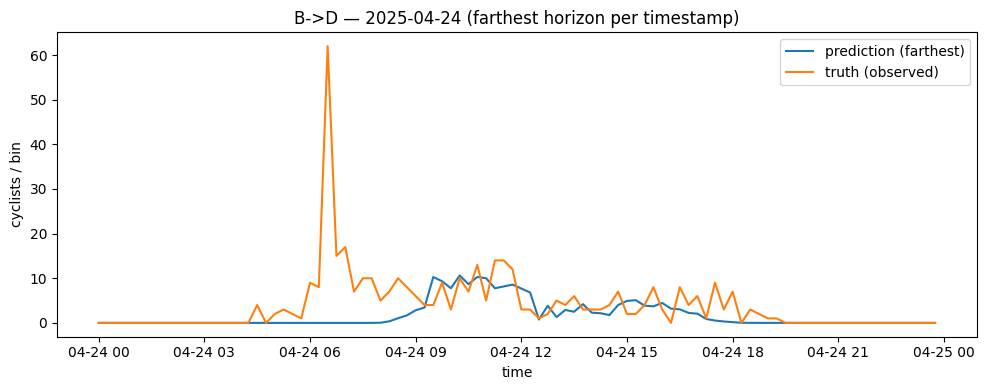

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

edge_uv = ('B','D')            # pick your edge
day_str = '2025-04-24'         # pick the calendar day to visualise (YYYY-MM-DD)

edge_str = f"{edge_uv[0]}->{edge_uv[1]}"
day = pd.to_datetime(day_str).date()

# 1) filter the edge & day
sel = df_pred[(df_pred['edge'] == edge_str) &
              (df_pred['timestamp'].dt.date == day)].copy()

# 2) keep the farthest forecast per (timestamp, edge) -> largest h
far = (sel.sort_values(['timestamp','h'])
          .drop_duplicates(['timestamp','edge'], keep='last'))

# 3) build time series and compare to truth (only where observed)
ts_pred_far = far.set_index('timestamp')['pred']
ts_true     = far[far['observed']].set_index('timestamp')['true']  # ground truth only where present

# metrics on common timestamps with truth
idx = ts_true.index.intersection(ts_pred_far.index)
mae_far  = float(np.mean(np.abs(ts_pred_far.reindex(idx) - ts_true.reindex(idx))))
rmse_far = float(np.sqrt(np.mean((ts_pred_far.reindex(idx) - ts_true.reindex(idx))**2)))
print(f"{edge_str} — farthest horizon only — {day_str}:  MAE={mae_far:.3f}, RMSE={rmse_far:.3f}")

# 4) plot
plt.figure(figsize=(10,4))
plt.plot(ts_pred_far.index, ts_pred_far.values, label='prediction (farthest)')
plt.plot(ts_true.index,     ts_true.values,     label='truth (observed)')
plt.title(f"{edge_str} — {day_str} (farthest horizon per timestamp)")
plt.xlabel("time"); plt.ylabel("cyclists / bin"); plt.legend(); plt.tight_layout(); plt.show()


Per-edge values at 2025-04-24 12:00:00 (horizon=closest)


,u,v,edge,observed,true,pred,abs_err
786483,B,D,B->D,True,3.0,7.779701,4.779701
786502,J,F,J->F,True,5.0,6.848699,1.848699
786494,F,J,F->J,True,4.0,5.855203,1.855203
786487,D,B,D->B,True,2.0,5.690666,3.690666
786481,A,C,A->C,True,2.0,3.051946,1.051946
786484,C,A,C->A,True,3.0,2.819308,0.180692
786516,N,P,N->P,True,1.0,2.645998,1.645998
786509,K,O,K->O,True,1.0,2.251744,1.251744
786498,I,E,I->E,True,1.0,1.800635,0.800635
786486,C,E,C->E,True,3.0,1.663162,1.336838


Top 15 by TRUE (observed) at 2025-04-24 12:00:00


,u,v,edge,true,pred,abs_err
786502,J,F,J->F,5.0,6.848699,1.848699
786494,F,J,F->J,4.0,5.855203,1.855203
786486,C,E,C->E,3.0,1.663162,1.336838
786484,C,A,C->A,3.0,2.819308,0.180692
786519,P,N,P->N,3.0,1.476118,1.523882
786483,B,D,B->D,3.0,7.779701,4.779701
786481,A,C,A->C,2.0,3.051946,1.051946
786517,O,K,O->K,2.0,0.992891,1.007109
786487,D,B,D->B,2.0,5.690666,3.690666
786497,H,I,H->I,1.0,0.276298,0.723702


C:\Users\raf\AppData\Local\Temp\ipykernel_32380\2728302451.py:116: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmapname)


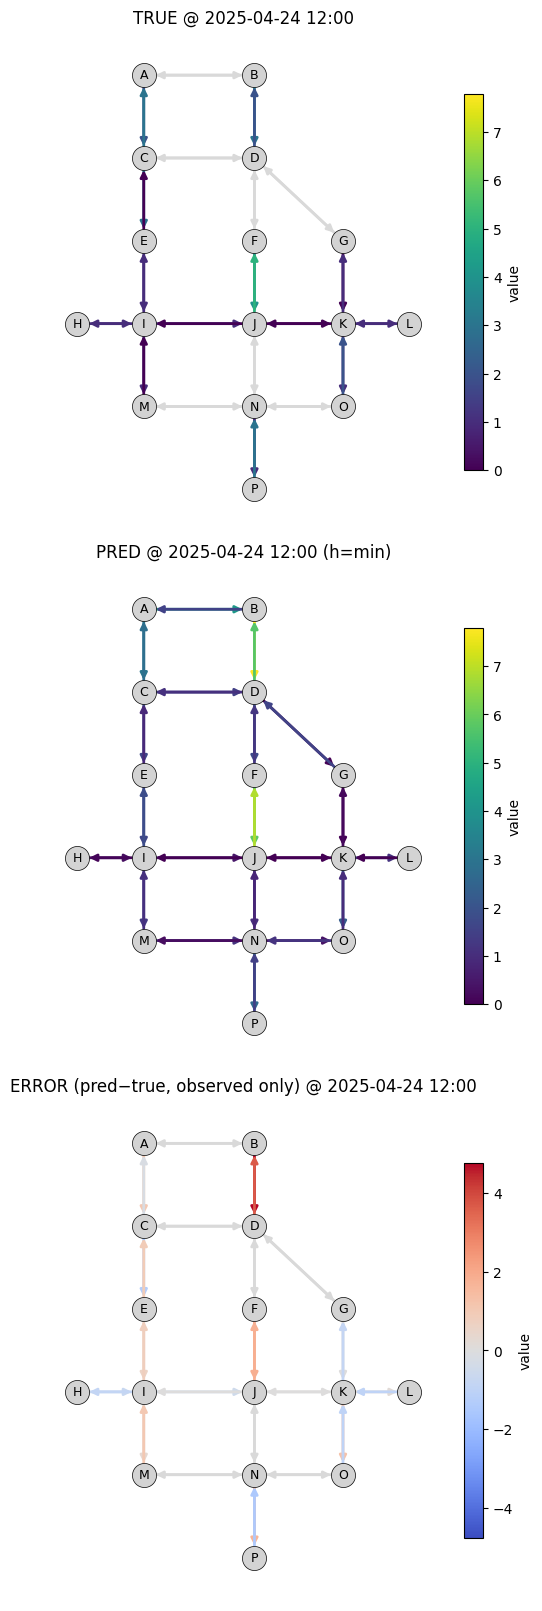

In [13]:
# === Day summary tables + network picture (peaks) ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt, networkx as nx
from matplotlib import cm, colors as mcolors
# ---- CONFIGURE ----
day_str   = '2025-04-24'   # day to inspect (YYYY-MM-DD)
time_str  = '12:00'        # local time within that day
use_closest = True         # horizon: True -> smallest h; False -> largest h
top_k = 15                 # table: show top-K edges by true or pred at the moment

# ---------- helpers ----------
def _select_by_h(df_edge_time, use_closest=True):
    if use_closest:
        return (df_edge_time.sort_values(['timestamp','h'])
                           .drop_duplicates(['timestamp','edge'], keep='first'))
    else:
        return (df_edge_time.sort_values(['timestamp','h'])
                           .drop_duplicates(['timestamp','edge'], keep='last'))

def _mae_rmse_on_observed(df_edge_day):
    g = df_edge_day[df_edge_day['observed']]
    if g.empty:
        return np.nan, np.nan
    err = g['pred'] - g['true']
    mae = np.abs(err).mean()
    rmse = np.sqrt((err**2).mean())
    return mae, rmse

def _edge_peak_tables(df_day_sel: pd.DataFrame) -> pd.DataFrame:
    # 0) ensure 'edge' column exists (fallback from u/v)
    if 'edge' not in df_day_sel.columns:
        df_day_sel = df_day_sel.copy()
        df_day_sel['edge'] = df_day_sel['u'].astype(str) + '->' + df_day_sel['v'].astype(str)

    # 1) TRUE peaks (use observed bins only)
    obs = df_day_sel[df_day_sel.get('observed', True)].copy()

    if obs.empty:
        # build an empty but correctly-typed table
        cols = ['edge','u','v','peak_true','t_true_peak','pred_at_true_peak',
                'abs_err_at_true_peak','peak_pred','t_pred_peak','true_at_pred_peak',
                'abs_err_at_pred_peak','mae_day','rmse_day','observed_bins','total_bins','observed_frac']
        return pd.DataFrame(columns=cols)

    obs_sorted = obs.sort_values(['edge','true'], ascending=[True, False])
    true_peaks = (obs_sorted.groupby('edge', as_index=False)
                           .first()[['edge','u','v','timestamp','true']]
                           .rename(columns={'timestamp':'t_true_peak','true':'peak_true'}))

    # predicted value at the time of the TRUE peak
    pred_at_true_peak = (df_day_sel[['edge','timestamp','pred']]
                         .merge(true_peaks[['edge','t_true_peak']],
                                left_on=['edge','timestamp'],
                                right_on=['edge','t_true_peak'],
                                how='right')
                         .rename(columns={'pred':'pred_at_true_peak'})
                         [['edge','pred_at_true_peak']])

    # 2) PRED peaks (on selected horizon rows)
    sel_sorted = df_day_sel.sort_values(['edge','pred'], ascending=[True, False])
    pred_peaks = (sel_sorted.groupby('edge', as_index=False)
                           .first()[['edge','timestamp','pred','true','observed']]
                           .rename(columns={'timestamp':'t_pred_peak','pred':'peak_pred',
                                            'true':'true_at_pred_peak','observed':'obs_at_pred_peak'}))

    # 3) Per-edge day stats (MAE/RMSE on observed bins only)
    stats_rows = []
    for e, g in df_day_sel.groupby('edge'):
        g_obs = g[g.get('observed', True)]
        if g_obs.empty:
            mae = rmse = np.nan
            obs_cnt = 0
        else:
            err = (g_obs['pred'] - g_obs['true']).to_numpy()
            mae = np.abs(err).mean()
            rmse = np.sqrt((err**2).mean())
            obs_cnt = int(g_obs.shape[0])
        tot_cnt = int(g.shape[0])
        stats_rows.append({
            'edge': e, 'mae_day': mae, 'rmse_day': rmse,
            'observed_bins': obs_cnt, 'total_bins': tot_cnt,
            'observed_frac': (obs_cnt / max(1, tot_cnt))
        })
    day_stats = pd.DataFrame(stats_rows)

    # 4) Join everything on a *column* 'edge'
    tbl = (true_peaks
           .merge(pred_at_true_peak, on='edge', how='left')
           .merge(pred_peaks,       on='edge', how='left')
           .merge(day_stats,        on='edge', how='left'))

    # 5) Absolute errors at peak times
    tbl['abs_err_at_true_peak'] = (tbl['pred_at_true_peak'] - tbl['peak_true']).abs()
    tbl['abs_err_at_pred_peak'] = (tbl['peak_pred'] - tbl['true_at_pred_peak']).abs()

    # nice ordering
    cols = ['edge','u','v','peak_true','t_true_peak','pred_at_true_peak','abs_err_at_true_peak',
            'peak_pred','t_pred_peak','true_at_pred_peak','abs_err_at_pred_peak',
            'mae_day','rmse_day','observed_bins','total_bins','observed_frac']
    return tbl[cols].sort_values('peak_true', ascending=False).reset_index(drop=True)



def _plot_network_values(POS, edges, values, title, vmin=None, vmax=None, cmapname='viridis', show_arrows=True, ax=None):
    if ax is None: ax = plt.gca()
    G = nx.DiGraph(); G.add_nodes_from(POS.keys()); G.add_edges_from(edges)
    edgelist = list(edges)

    vals = np.array([values.get((u,v), np.nan) for (u,v) in edgelist], float)
    # choose scale
    if vmin is None: vmin = float(np.nanmin(vals)) if np.isfinite(vals).any() else 0.0
    if vmax is None: vmax = float(np.nanmax(vals)) if np.isfinite(vals).any() else 1.0
    if not np.isfinite(vmin): vmin = 0.0
    if (not np.isfinite(vmax)) or vmax <= vmin: vmax = vmin + 1.0

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = cm.get_cmap(cmapname)
    # colors: NaNs -> light gray
    colors = [cmap(norm(v)) if np.isfinite(v) else (0.85,0.85,0.85,1.0) for v in vals]
    # # widths: based on |value| so negatives still visible (error panel)
    # scale = vmax - vmin if vmax > vmin else 1.0
    # widths = 1.0 + 4.0 * (np.abs(vals - (vmin + scale/2.0)) / (scale/2.0))
    # widths = np.clip(widths, 0.5, 5.0)
    widths = np.full_like(vals, 2.0, dtype=float)


    ax.set_title(title)
    nx.draw_networkx_nodes(G, POS, node_size=300, node_color='lightgray', edgecolors='k', linewidths=0.5, ax=ax)
    nx.draw_networkx_edges(G, POS, edgelist=edgelist, width=widths,
                           edge_color=colors, arrows=show_arrows,
                           arrowstyle='-|>', arrowsize=10, ax=ax)
    nx.draw_networkx_labels(G, POS, font_size=9, ax=ax)

    sm = cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    ax.figure.colorbar(sm, ax=ax, shrink=0.75).set_label('value')
    ax.set_axis_off()
    return sm


# # ------------------- main -------------------
# # Select day + deduplicate horizons
# day = pd.to_datetime(day_str).date()
# df_day = df_pred[df_pred['timestamp'].dt.date == day].copy()
# df_day = _select_by_h(df_day, use_closest=use_closest)

# # Summary tables
# edge_tbl = _edge_peak_tables(df_day)

# # Show top-K edges by true daily peak
# print(f"Daily peak summary (top {top_k}) — {day_str}  (horizon={'closest' if use_closest else 'farthest'})")
# display(edge_tbl.head(top_k))

# # Network totals table (when whole-network truth peaks)
# obs = df_day[df_day['observed']]
# net_by_ts = (obs.groupby('timestamp')[['true','pred']]
#                .sum().rename(columns={'true':'true_total','pred':'pred_total'})
#                .sort_index())
# if not net_by_ts.empty:
#     idx_peak = net_by_ts['true_total'].idxmax()
#     print("\nNetwork totals — top rows (true_total desc):")
#     display(net_by_ts.sort_values('true_total', ascending=False).head(10))
#     print(f"Peak network truth at: {idx_peak}  value={float(net_by_ts.loc[idx_peak,'true_total']):.1f}")

# # Build edge->daily peak dicts (truth/pred) for plotting
# # Truth: daily max of true over observed bins; Pred: daily max of pred (selected horizon)
# edge_true_peaks = {}
# edge_pred_peaks = {}
# for (u,v), g in df_day.groupby(['u','v']):
#     g_obs = g[g['observed']]
#     if not g_obs.empty:
#         edge_true_peaks[(u,v)] = float(g_obs['true'].max())
#     else:
#         edge_true_peaks[(u,v)] = 0.0
#     edge_pred_peaks[(u,v)] = float(g['pred'].max()) if not g.empty else 0.0

# # Common color scale so plots are comparable
# all_max = max(max(edge_true_peaks.values() or [1.0]), max(edge_pred_peaks.values() or [1.0]))
# all_max = all_max if all_max > 0 else 1.0

# # Plots
# fig, axs = plt.subplots(1, 2, figsize=(12,5), constrained_layout=True)
# _plot_network_values(POS, DIRECTED_EDGES, edge_true_peaks,
#                      f"Daily peak TRUE per directed edge — {day_str}",
#                      vmin=0, vmax=all_max, ax=axs[0])
# _plot_network_values(POS, DIRECTED_EDGES, edge_pred_peaks,
#                      f"Daily peak PRED per directed edge — {day_str}",
#                      vmin=0, vmax=all_max, ax=axs[1])
# plt.show()


# # Optional: save artifacts
# edge_tbl.to_csv(f"edge_daily_peaks_{day_str.replace('-','')}.csv", index=False)
# plt.savefig(f"network_daily_peaks_{day_str.replace('-','')}.png", dpi=180, bbox_inches='tight')
# print("Saved:",
#       f"edge_daily_peaks_{day_str.replace('-','')}.csv",
#       f"network_daily_peaks_{day_str.replace('-','')}.png")

# ---------- main ----------
# 1) pick the closest timestamp to the requested moment on that day
t_req = pd.Timestamp(f"{day_str} {time_str}")
day = t_req.date()

df_day = df_pred[df_pred['timestamp'].dt.date == day].copy()
if df_day.empty:
    raise ValueError(f"No predictions for day {day_str} in df_pred.")

ts_np   = df_day['timestamp'].values.astype('datetime64[ns]')
t_req_np = np.datetime64(t_req)
idx = np.argmin(np.abs(ts_np - t_req_np))
t_sel = pd.Timestamp(ts_np[idx])
if t_sel != t_req:
    print(f"Using closest timestamp on {day_str}: requested {t_req.time()}, selected {pd.Timestamp(t_sel).time()}")

# 2) select rows at that timestamp and resolve horizon duplicates
df_t = df_day[df_day['timestamp'] == t_sel].copy()
if 'edge' not in df_t.columns:
    df_t['edge'] = df_t['u'].astype(str) + '->' + df_t['v'].astype(str)
df_t = _select_by_h(df_t, use_closest=use_closest)

# 3) build per-edge dicts
edge_true = {}
edge_pred = {}
edge_err  = {}
for (u,v), g in df_t.groupby(['u','v']):
    pred = float(g['pred'].iloc[0])
    edge_pred[(u,v)] = pred
    if bool(g['observed'].iloc[0]):
        tru = float(g['true'].iloc[0])
    else:
        tru = np.nan  # no truth available at that instant
    edge_true[(u,v)] = tru
    edge_err[(u,v)]  = (pred - tru) if np.isfinite(tru) else np.nan

# 4) summary tables at the moment
tbl = (df_t[['u','v','edge','observed','true','pred']]
       .assign(abs_err=lambda d: np.where(d['observed'], (d['pred']-d['true']).abs(), np.nan))
       .sort_values(['observed','pred'], ascending=[False, False]))
print(f"Per-edge values at {pd.Timestamp(t_sel)} (horizon={'closest' if use_closest else 'farthest'})")
display(tbl.head(top_k))

# top by TRUE (observed only)
tbl_true = (df_t[df_t['observed']][['u','v','edge','true','pred']]
            .assign(abs_err=lambda d: (d['pred']-d['true']).abs())
            .sort_values('true', ascending=False))
print(f"Top {top_k} by TRUE (observed) at {pd.Timestamp(t_sel)}")
display(tbl_true.head(top_k))

# 5) draw network: TRUE / PRED / ERROR
vmax_tp = np.nanmax([*edge_true.values(), *edge_pred.values(), 1.0])
vmax_tp = vmax_tp if np.isfinite(vmax_tp) and vmax_tp > 0 else 1.0
err_vals = np.array([v for v in edge_err.values() if np.isfinite(v)])
err_max = float(np.nanmax(np.abs(err_vals))) if err_vals.size else 1.0

fig, axs = plt.subplots(3, 1, figsize=(5,16), constrained_layout=True)
_plot_network_values(POS, DIRECTED_EDGES, edge_true,
                     f"TRUE @ {pd.Timestamp(t_sel).strftime('%Y-%m-%d %H:%M')}",
                     vmin=0, vmax=vmax_tp, cmapname='viridis', ax=axs[0])
_plot_network_values(POS, DIRECTED_EDGES, edge_pred,
                     f"PRED @ {pd.Timestamp(t_sel).strftime('%Y-%m-%d %H:%M')} (h={'min' if use_closest else 'max'})",
                     vmin=0, vmax=vmax_tp, cmapname='viridis', ax=axs[1])
_plot_network_values(POS, DIRECTED_EDGES, edge_err,
                     f"ERROR (pred−true, observed only) @ {pd.Timestamp(t_sel).strftime('%Y-%m-%d %H:%M')}",
                     vmin=-err_max, vmax=err_max, cmapname='coolwarm', ax=axs[2])
plt.show()

B->D — 2025-04-24
  Model     MAE=1.906  RMSE=5.061
  HistMean  MAE=2.882  RMSE=6.326
  LinReg    MAE=2.587  RMSE=5.328


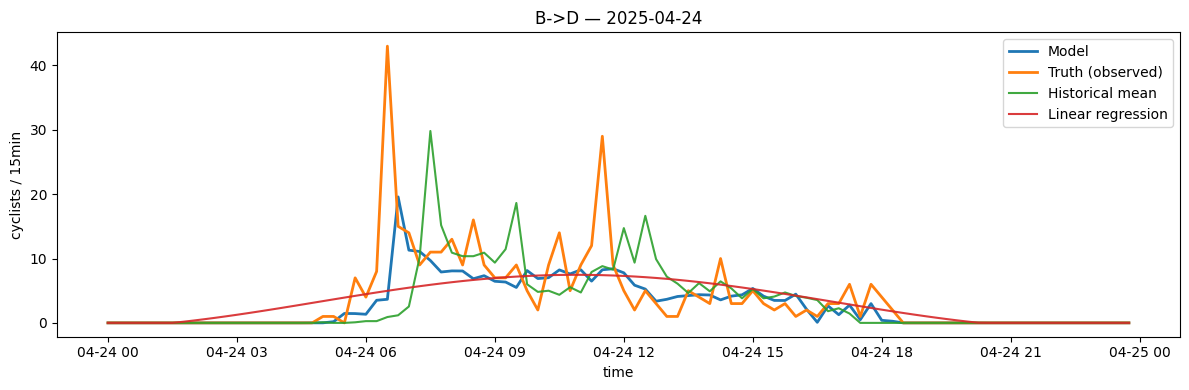

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def add_lags(df_edge: pd.DataFrame, lags_steps: Iterable[int]) -> pd.DataFrame:
    """
    Add lag features to a single-edge dataframe.
    Expects df_edge to have an index = timestamps and a column 'true'.
    Returns a copy with columns lag{L} and drops rows that don't have all lags.
    """
    out = df_edge.copy()
    for L in lags_steps:
        out[f"lag{L}"] = out["true"].shift(L)
    return out.dropna()

def _lag_steps_from_times(idx: pd.DatetimeIndex) -> list[int]:
    """Compute steps for lags 1,2,3, plus 1 day and 1 week based on the series frequency."""
    # infer step size robustly
    if len(idx) >= 2:
        step = (idx[1] - idx[0])
    else:
        # fallback if something odd
        step = pd.Timedelta(pd.infer_freq(idx) or "15min")
    steps_per_day  = int(pd.Timedelta("1D") / step)
    steps_per_week = int(pd.Timedelta("7D") / step)
    return [1, 2, 3, steps_per_day, steps_per_week]



# ==== CONFIGURE WHAT TO PLOT ====
edge_uv  = ('B','D')            # edge to visualize
day_str  = '2025-04-24'         # calendar day (YYYY-MM-DD)
use_slices_if_available = True  # if your runner returns 'slices'

# ==== Canonical truth (frozen) ====
times  = artifacts["times"]
X_true = artifacts["X_true"]     # [T,E]
M_obs  = artifacts["M_obs"]      # [T,E]
E = X_true.shape[1]

edge_list = list(network_cfg.directed_edges)
e_idx = edge_list.index(edge_uv)
edge_str = f"{edge_uv[0]}->{edge_uv[1]}"
day = pd.to_datetime(day_str).date()

truth = pd.Series(X_true[:, e_idx], index=times, name='true')
mask  = pd.Series(M_obs[:, e_idx].astype(bool), index=times)
truth = truth.where(mask)  # NaN where not observed

# Train indices (for baselines) — prefer runner's slices if present
if use_slices_if_available and "slices" in artifacts:
    train_slice = artifacts["slices"]["train"]
else:
    n = len(times)
    n_train = int(0.6*n)
    train_slice = slice(0, n_train)

times_train  = times[train_slice]
truth_train  = truth.loc[times_train].dropna()


# ==== 1) Model prediction series for the day (choose smallest horizon per ts) ====
sel = df_pred[(df_pred['edge'] == edge_str) &
              (df_pred['timestamp'].dt.date == day)].copy()
sel = (sel.sort_values(['timestamp','h'])
           .drop_duplicates(['timestamp','edge'], keep='first'))

pred_day = sel.set_index('timestamp')['pred'].rename('Model')

# ==== 2) Historical-Mean baseline (weekday × time-of-day, train only) ====
def _wd_tod_key(idx: pd.DatetimeIndex):
    return pd.MultiIndex.from_arrays(
        [idx.dayofweek, idx.hour * 60 + idx.minute],
        names=['dow','min_of_day']
    )

# build template over training
train_df = pd.DataFrame({
    'true': truth_train.values,
}, index=truth_train.index)
train_df['dow'] = train_df.index.dayofweek
train_df['min_of_day'] = train_df.index.hour * 60 + train_df.index.minute

hist_table = (train_df
              .groupby(['dow','min_of_day'])['true']
              .mean())  # mean over all training weeks

import re
freq_str = times.inferred_freq or pd.infer_freq(times)
minutes_per_period = int(re.findall(r'\d+', freq_str)[0]) if freq_str else 1

# map for the plotting day
idx_day = pd.date_range(day_str, periods=24*60 // minutes_per_period,  # fallback if inferred
                        freq=times.freq or pd.infer_freq(times), tz=times.tz)
idx_day = pd.DatetimeIndex([t for t in times if t.date() == day])  # safer: use actual timeline entries
day_keys = _wd_tod_key(idx_day)
hist_pred_day = pd.Series(index=idx_day, dtype=float, name='HistMean')
hist_pred_day.loc[idx_day] = hist_table.reindex(day_keys, fill_value=np.nan).values
# backfill any NaNs with global train mean to be safe
global_train_mean = float(truth_train.mean()) if not truth_train.empty else 0.0
hist_pred_day = hist_pred_day.fillna(global_train_mean)

# ==== 3) Linear Regression baseline (train only, no AR lags) ====
def _time_features(idx: pd.DatetimeIndex) -> np.ndarray:
    """[T, 1+4] = [bias, tod_sin, tod_cos, dow_sin, dow_cos]"""
    idx = pd.DatetimeIndex(idx)
    sec_in_day = 24*3600
    tod = (idx.hour*3600 + idx.minute*60 + idx.second).to_numpy()
    theta_tod = 2*np.pi * tod / sec_in_day
    dow = idx.dayofweek.to_numpy()
    theta_dow = 2*np.pi * dow / 7.0
    Xf = np.column_stack([
        np.ones(len(idx), dtype=np.float32),
        np.sin(theta_tod), np.cos(theta_tod),
        np.sin(theta_dow), np.cos(theta_dow),
    ]).astype(np.float32)
    return Xf

# fit on observed train bins only
Xtr = _time_features(truth_train.index)
ytr = truth_train.values.astype(np.float32)
# closed-form least squares
beta, *_ = np.linalg.lstsq(Xtr, ytr, rcond=None)

# predict for the plotting day
Xte = _time_features(idx_day)
lin_pred_day = pd.Series(Xte @ beta, index=idx_day, name='LinReg').clip(lower=0.0)

# ==== 4) Truth for the day ====
truth_day = truth.loc[idx_day].rename('Truth')

# ==== 5) Metrics on common timestamps with truth ====
def _metrics(yhat: pd.Series, ytrue: pd.Series):
    common = ytrue.dropna().index.intersection(yhat.index)
    if len(common) == 0:
        return np.nan, np.nan
    d = (yhat.reindex(common) - ytrue.reindex(common)).to_numpy()
    return float(np.mean(np.abs(d))), float(np.sqrt(np.mean(d**2)))

mae_m, rmse_m = _metrics(pred_day, truth_day)
mae_h, rmse_h = _metrics(hist_pred_day, truth_day)
mae_l, rmse_l = _metrics(lin_pred_day, truth_day)

print(f"{edge_str} — {day_str}")
print(f"  Model     MAE={mae_m:.3f}  RMSE={rmse_m:.3f}")
print(f"  HistMean  MAE={mae_h:.3f}  RMSE={rmse_h:.3f}")
print(f"  LinReg    MAE={mae_l:.3f}  RMSE={rmse_l:.3f}")

# ==== 6) Plot all together ====
plt.figure(figsize=(12,4))
plt.plot(pred_day.index,       pred_day.values,       label='Model', lw=2)
plt.plot(truth_day.index,      truth_day.values,      label='Truth (observed)', lw=2)
plt.plot(hist_pred_day.index,  hist_pred_day.values,  label='Historical mean', lw=1.5, alpha=0.9)
plt.plot(lin_pred_day.index,   lin_pred_day.values,   label='Linear regression', lw=1.5, alpha=0.9)
plt.title(f"{edge_str} — {day_str}")
plt.xlabel("time"); plt.ylabel(f"cyclists / {times.freqstr or 'bin'}")
plt.legend()
plt.tight_layout(); plt.show()



In [15]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

# ---------- utilities ----------
def _time_features(idx: pd.DatetimeIndex) -> np.ndarray:
    """[T, 5] = [bias, tod_sin, tod_cos, dow_sin, dow_cos]"""
    idx = pd.DatetimeIndex(idx)
    sec_in_day = 24*3600
    tod = (idx.hour*3600 + idx.minute*60 + idx.second).to_numpy()
    theta_tod = 2*np.pi * tod / sec_in_day
    dow = idx.dayofweek.to_numpy()
    theta_dow = 2*np.pi * dow / 7.0
    Xf = np.column_stack([
        np.ones(len(idx), dtype=np.float32),
        np.sin(theta_tod), np.cos(theta_tod),
        np.sin(theta_dow), np.cos(theta_dow),
    ]).astype(np.float32)
    return Xf

def _masked_metrics(yhat, ytrue, mask):
    """yhat,ytrue,mask : arrays [T,E] (mask=1 on observed). Returns overall MAE/RMSE and per-edge."""
    mask = mask.astype(bool)
    # overall
    num = mask.sum()
    if num == 0:
        overall = {"MAE": np.nan, "RMSE": np.nan}
    else:
        err = (yhat - ytrue)
        mae = np.abs(err)[mask].mean()
        rmse = np.sqrt((err[mask]**2).mean())
        overall = {"MAE": float(mae), "RMSE": float(rmse)}
    # per-edge
    per_edge = []
    E = ytrue.shape[1]
    for e in range(E):
        m = mask[:, e]
        if m.any():
            e_err = (yhat[:, e] - ytrue[:, e])[m]
            per_edge.append((e, float(np.abs(e_err).mean()), float(np.sqrt((e_err**2).mean()))))
        else:
            per_edge.append((e, np.nan, np.nan))
    per_edge_df = pd.DataFrame(per_edge, columns=["edge_idx","MAE","RMSE"])
    return overall, per_edge_df

def _rollout_model_h0(model, X, M, exog, H_in, H_out, device):
    """Return timeline-aligned horizon-0 next-step predictions Xhat [T,E]."""
    model.eval()
    T, E = X.shape
    Xhat = np.zeros((T, E), dtype=np.float32)
    ds_all = preprocessing.WindowedEdgeDataset(X, M, exog, H_in, H_out)
    loader_all = DataLoader(ds_all, batch_size=256, shuffle=False, drop_last=False,
                            pin_memory=str(device).startswith("cuda"))
    t0 = H_in
    off = 0
    with torch.no_grad():
        for batch in loader_all:
            xb = batch["x"].to(device)
            yb = model(xb).cpu().numpy()  # [B,H_out,E]
            B = yb.shape[0]
            Xhat[t0 + off : t0 + off + B, :] = yb[:, 0, :]  # horizon 0
            off += B
    return Xhat

# ---------- data from artifacts ----------
times  = artifacts["times"]
X_true = artifacts["X_true"]    # [T,E]
M_obs  = artifacts["M_obs"]     # [T,E] 1 if observed
cfg    = artifacts["cfg"]
loaders = artifacts["loaders"]

# test slice (use runner's splits if available)
if "slices" in artifacts:
    s_test = artifacts["slices"]["test"]
else:
    n = len(times); n_train = int(0.6*n); n_val = int(0.2*n)
    s_test = slice(n_train+n_val, n)

# need exog used during training for rollout (take from any dataset)
exog_full = None
for split in ("train","val","test"):
    if split in loaders:
        # exog_full = loaders[split].dataset.exog_full   # if you stored it there
        exog_full = getattr(loaders[split].dataset, "exog_full", None)
        break
if exog_full is None:
    # fallback: rebuild from features (same config as training, no preds blended)
    A = preprocessing.build_line_graph_adjacency(network_cfg.directed_edges).astype(np.float32)
    A_bin = (A > 0).astype(np.float32)
    exog_full = features.add_exogenous(times, X_true.shape[1], cfg, weather_df=None,
                                       X=X_true, M=M_obs, A_bin=A_bin, use_graph_fill=True,
                                       lags_self=(1,2,3,6,12), lags_neigh=(1,2,3),
                                       ema_alpha=0.7, fill_weights=(0.7,0.3,0.0), Xhat_prev=None)

# ---------- 1) MODEL timeline prediction ----------
X_model = _rollout_model_h0(artifacts["model"], X_true, M_obs, exog_full, cfg.H_in, cfg.H_out, cfg.device)

# ---------- 2) HISTORICAL MEAN baseline (per edge, train only) ----------
E = X_true.shape[1]
dow = times.dayofweek.to_numpy()
mod = times.hour.to_numpy()*60 + times.minute.to_numpy()

# train mask for rows
if "slices" in artifacts:
    s_train = artifacts["slices"]["train"]
else:
    s_train = slice(0, int(0.6*len(times)))

X_hist = np.zeros_like(X_true, dtype=np.float32)
for e in range(E):
    # observed train rows for this edge
    m_tr = M_obs[s_train, e].astype(bool)
    if not m_tr.any():
        X_hist[:, e] = X_true[s_train, e].mean() if m_tr.size else 0.0
        continue
    df_tr = pd.DataFrame({
        "dow": dow[s_train][m_tr],
        "mod": mod[s_train][m_tr],
        "y":   X_true[s_train, e][m_tr].astype(np.float32)
    })
    mean_tbl = df_tr.groupby(["dow","mod"])["y"].mean()
    # map to all times; backfill with global train mean for unseen keys
    global_mean = float(df_tr["y"].mean())
    keys = pd.MultiIndex.from_arrays([dow, mod], names=["dow","mod"])
    vals = mean_tbl.reindex(keys, fill_value=np.nan).to_numpy()
    vals = np.where(np.isfinite(vals), vals, global_mean)
    X_hist[:, e] = vals.astype(np.float32)

# ---------- 3) LINEAR REGRESSION baseline (per edge, train only) ----------
F = _time_features(times)
X_lin = np.zeros_like(X_true, dtype=np.float32)
for e in range(E):
    m_tr = M_obs[s_train, e].astype(bool)
    if not m_tr.any():
        X_lin[:, e] = 0.0
        continue
    Xtr = F[s_train][m_tr]
    ytr = X_true[s_train, e][m_tr].astype(np.float32)
    beta, *_ = np.linalg.lstsq(Xtr, ytr, rcond=None)
    X_lin[:, e] = (F @ beta).astype(np.float32).clip(min=0.0)

# ---------- evaluate on TEST slice (observed bins only) ----------
y_true_te = X_true[s_test]
m_obs_te  = M_obs[s_test].astype(bool)

overall_model, per_edge_model = _masked_metrics(X_model[s_test], y_true_te, m_obs_te)
overall_hist,  per_edge_hist  = _masked_metrics(X_hist[s_test],  y_true_te, m_obs_te)
overall_lin,   per_edge_lin   = _masked_metrics(X_lin[s_test],   y_true_te, m_obs_te)

print("== Overall MAE / RMSE on TEST (observed bins) ==")
print(f"Model:     MAE={overall_model['MAE']:.3f}  RMSE={overall_model['RMSE']:.3f}    toMAE={overall_model['MAE']/overall_hist['MAE']*100:.2f}%")
print(f"HistMean:  MAE={overall_hist['MAE']:.3f}   RMSE={overall_hist['RMSE']:.3f}    toMAE={overall_hist['MAE']/overall_hist['MAE']*100:.2f}%")
print(f"LinReg:    MAE={overall_lin['MAE']:.3f}    RMSE={overall_lin['RMSE']:.3f}    toMAE={overall_lin['MAE']/overall_hist['MAE']*100:.2f}%")

# ---------- per-edge tables ----------
edge_labels = [f"{u}->{v}" for (u,v) in network_cfg.directed_edges]

# 1) Build a LONG table; no overlapping-column issue.
per_edge_long = pd.concat([
    per_edge_model.assign(method="Model"),
    per_edge_hist.assign(method="HistMean"),
    per_edge_lin.assign(method="LinReg"),
], ignore_index=True)

# 2) Map edge indices to readable labels
per_edge_long["edge"] = per_edge_long["edge_idx"].map(dict(enumerate(edge_labels)))

# 3) Pivot to a WIDE summary: (MAE/RMSE) × method
per_edge_wide = (per_edge_long
                 .pivot_table(index="edge", columns="method", values=["MAE","RMSE"]))

# 4) Nicely sorted and rounded
per_edge_wide = per_edge_wide.sort_values(("MAE", "Model")).round(3)

display(per_edge_wide)
# The above merge stacks oddly; instead build clean long-format:
per_edge_long = pd.concat([
    per_edge_model.assign(method="Model"),
    per_edge_hist.assign(method="HistMean"),
    per_edge_lin.assign(method="LinReg"),
], ignore_index=True)
per_edge_long["edge"] = per_edge_long["edge_idx"].map(dict(enumerate(edge_labels)))
# nice wide format
per_edge_wide = (per_edge_long
                 .pivot_table(index="edge", columns="method", values=["MAE","RMSE"]))
display(per_edge_wide.sort_values(("MAE","Model")).round(3))


== Overall MAE / RMSE on TEST (observed bins) ==
Model:     MAE=0.626  RMSE=1.912    toMAE=71.30%
HistMean:  MAE=0.878   RMSE=2.446    toMAE=100.00%
LinReg:    MAE=0.893    RMSE=2.211    toMAE=101.65%


MAE                   RMSE              
method HistMean LinReg  Model HistMean LinReg  Model
edge                                                
J->K      1.796  1.969  0.007    3.441  2.617  0.049
K->J      1.169  1.287  0.009    2.219  1.717  0.069
J->I      0.078  0.084  0.061    0.283  0.277  0.288
G->K      0.100  0.107  0.081    0.361  0.353  0.361
L->K      0.175  0.184  0.155    0.459  0.450  0.462
K->G      0.234  0.258  0.218    0.672  0.654  0.709
I->J      0.396  0.420  0.333    0.947  0.869  0.847
I->H      0.354  0.402  0.340    0.742  0.739  0.804
H->I      0.387  0.410  0.347    0.973  0.921  0.911
M->I      0.465  0.485  0.477    0.903  0.873  0.942
E->I      0.506  0.528  0.489    1.149  1.125  1.127
I->M      0.500  0.519  0.507    0.969  0.949  1.020
K->L      0.544  0.552  0.524    1.094  1.043  1.098
I->E      0.553  0.561  0.557    1.080  1.043  1.090
C->E      0.573  0.605  0.568    1.126  1.110  1.151
P->N      0.702  0.758  0.608    1.620  1.666  1.411
E->C      0.709  0.705  0.618    1.564  1.406  1.395
A->C      0.776  0.800  0.629    1.832  1.677  1.537
O->K      0.739  0.784  0.634    1.816  1.679  1.696
N->P      0.815  0.805  0.683    1.948  1.785  1.670
K->O      0.872  0.855  0.689    2.232  2.008  1.932
C->A      0.981  1.092  0.846    2.041  2.107  1.786
J->F      1.864  1.865  1.330    3.698  3.455  2.972
F->J      2.008  1.781  1.354    4.501  3.748  3.614
D->B      2.315  2.480  1.887    4.493  4.748  3.845
B->D      3.228  2.918  2.333    7.071  6.120  5.422

MAE                   RMSE              
method HistMean LinReg  Model HistMean LinReg  Model
edge                                                
J->K      1.796  1.969  0.007    3.441  2.617  0.049
K->J      1.169  1.287  0.009    2.219  1.717  0.069
J->I      0.078  0.084  0.061    0.283  0.277  0.288
G->K      0.100  0.107  0.081    0.361  0.353  0.361
L->K      0.175  0.184  0.155    0.459  0.450  0.462
K->G      0.234  0.258  0.218    0.672  0.654  0.709
I->J      0.396  0.420  0.333    0.947  0.869  0.847
I->H      0.354  0.402  0.340    0.742  0.739  0.804
H->I      0.387  0.410  0.347    0.973  0.921  0.911
M->I      0.465  0.485  0.477    0.903  0.873  0.942
E->I      0.506  0.528  0.489    1.149  1.125  1.127
I->M      0.500  0.519  0.507    0.969  0.949  1.020
K->L      0.544  0.552  0.524    1.094  1.043  1.098
I->E      0.553  0.561  0.557    1.080  1.043  1.090
C->E      0.573  0.605  0.568    1.126  1.110  1.151
P->N      0.702  0.758  0.608    1.620  1.666  1.411
E->C      0.709  0.705  0.618    1.564  1.406  1.395
A->C      0.776  0.800  0.629    1.832  1.677  1.537
O->K      0.739  0.784  0.634    1.816  1.679  1.696
N->P      0.815  0.805  0.683    1.948  1.785  1.670
K->O      0.872  0.855  0.689    2.232  2.008  1.932
C->A      0.981  1.092  0.846    2.041  2.107  1.786
J->F      1.864  1.865  1.330    3.698  3.455  2.972
F->J      2.008  1.781  1.354    4.501  3.748  3.614
D->B      2.315  2.480  1.887    4.493  4.748  3.845
B->D      3.228  2.918  2.333    7.071  6.120  5.422